# 03 · Prices and rents (Q3, Q4 preview)

**Question (docs/01 §3, Q3).** What is the price per sq m by area, property type and bedrooms, and how fast is it growing? Also a first look at Q4 (gross yields).

**Definitions.**
- *Median AED per sq m*: the exact median over clean market sales (`is_clean_market_sale`: market sales without C4–C6, C16 or C18 quality flags).
- *Area-weighted AED per sq m*: Σ AED ÷ Σ sq m over clean sales within the class area cap (apartments 1,000 sq m, villas 3,000). It weighs large units more, so it runs above the median for apartments.
- *New rent per sq m*: the median annual rent ÷ sq m over new market rents (`is_market_rent`: new, single-unit contracts, comparable property types, rule C11 applied, with a real area).
- **Min-n**: a segment with fewer than 20 observations shows no value (blank), per CLAUDE.md.

Residential apartments and villas / townhouses are the conformed property types 101 and 102. All areas are sq m and all money is AED. **Scope:** 2004 → 2026-09-25; **2026 is partial**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from dubai_property import config
from dubai_property.analysis import common
from dubai_property.analysis import plotting as P
from dubai_property.analysis import prices_rents as pr

P.apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SNAP = common.snapshot_date()
APT, VILLA = config.RESIDENTIAL_HOMES_KEYS
print("Data snapshot:", SNAP)

Data snapshot: 2026-09-25


## 1. AED per sq m by year: apartments and villas

In [2]:
pp = pr.ppsqm_by_year()
display(
    pp.pivot(
        index="year",
        columns="property_type_label",
        values=["clean_sales", "median_ppsqm_aed", "aw_ppsqm_aed"],
    ).loc[2008:]
)

clean_sales                                  \
property_type_label Residential · Apartment Residential · Villa / Townhouse   
year                                                                          
2008                             10,596.000                       3,700.000   
2009                             42,302.000                       2,426.000   
2010                             22,395.000                       2,212.000   
2011                             16,772.000                       2,069.000   
2012                             20,430.000                       3,021.000   
2013                             36,098.000                       6,349.000   
2014                             30,711.000                       6,082.000   
2015                             22,906.000                       4,975.000   
2016                             22,454.000                       4,605.000   
2017                             26,351.000                       6,352.000   
2018                             19,538.000                       3,365.000   
2019                             22,805.000                       6,564.000   
2020                             19,063.000                       5,679.000   
2021                             34,383.000                      10,284.000   
2022                             60,806.000                      11,339.000   
2023                             91,232.000                      14,112.000   
2024                            132,476.000                      18,064.000   
2025                            162,210.000                      15,220.000   
2026                             91,773.000                       9,402.000   

                           median_ppsqm_aed                                  \
property_type_label Residential · Apartment Residential · Villa / Townhouse   
year                                                                          
2008                              6,674.555                       4,757.220   
2009                              9,017.975                       5,381.960   
2010                              9,709.720                       4,809.705   
2011                              9,144.905                       4,688.690   
2012                              9,846.015                       4,860.410   
2013                             11,125.050                       6,079.120   
2014                             12,932.350                       7,866.185   
2015                             11,906.950                       8,004.060   
2016                             11,805.220                       8,909.480   
2017                             12,470.980                       8,081.625   
2018                             12,585.070                       7,536.540   
2019                             12,977.750                       7,543.540   
2020                             11,314.290                       7,528.350   
2021                             12,474.850                       8,586.315   
2022                             16,237.960                       9,021.410   
2023                             16,433.270                      11,359.325   
2024                             17,631.190                      14,351.880   
2025                             18,656.720                      15,699.605   
2026                             18,567.940                      18,671.775   

                               aw_ppsqm_aed                                  
property_type_label Residential · Apartment Residential · Villa / Townhouse  
year                                                                         
2008                              9,486.930                       5,222.008  
2009                             10,530.376                       5,307.090  
2010                             11,696.641                       4,717.575  
2011                             11,130.985                       4,634.964  
2012    

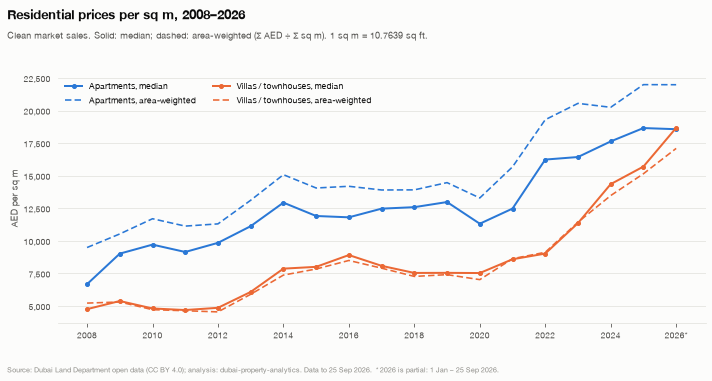

In [3]:
fig, ax = P.figure(size=(10, 5.2))
p = pp[pp["year"] >= 2008]
for key, name, series in [
    (APT, "Apartments", "apartment"),
    (VILLA, "Villas / townhouses", "villa"),
]:
    d = p[p["property_type_key"] == key]
    ax.plot(d["year"], d["median_ppsqm_aed"], color=P.SERIES[series], marker="o", ms=4)
    ax.plot(d["year"], d["aw_ppsqm_aed"], color=P.SERIES[series], ls=(0, (4, 2)), lw=1.6)
    ax.lines[-2].set_label(f"{name}, median")
    ax.lines[-1].set_label(f"{name}, area-weighted")
ax.legend(loc="upper left", ncols=2)
ax.set_ylabel("AED per sq m")
P.count_axis(ax)
P.year_ticks(ax, p["year"], SNAP)
P.titled(
    fig,
    "Residential prices per sq m, 2008–2026",
    "Clean market sales. Solid: median; dashed: area-weighted (Σ AED ÷ Σ sq m). 1 sq m = 10.7639 sq ft.",
)
P.add_source(fig, SNAP)
P.save(fig, "q3_price_per_sqm_apartments_villas")
plt.show()

## 2. By zone

There are 19 market zones (seed_area). Blank cells are below the min-n rule. Years from 2010, because earlier years are thin and distorted by registration timing (notebook 01).

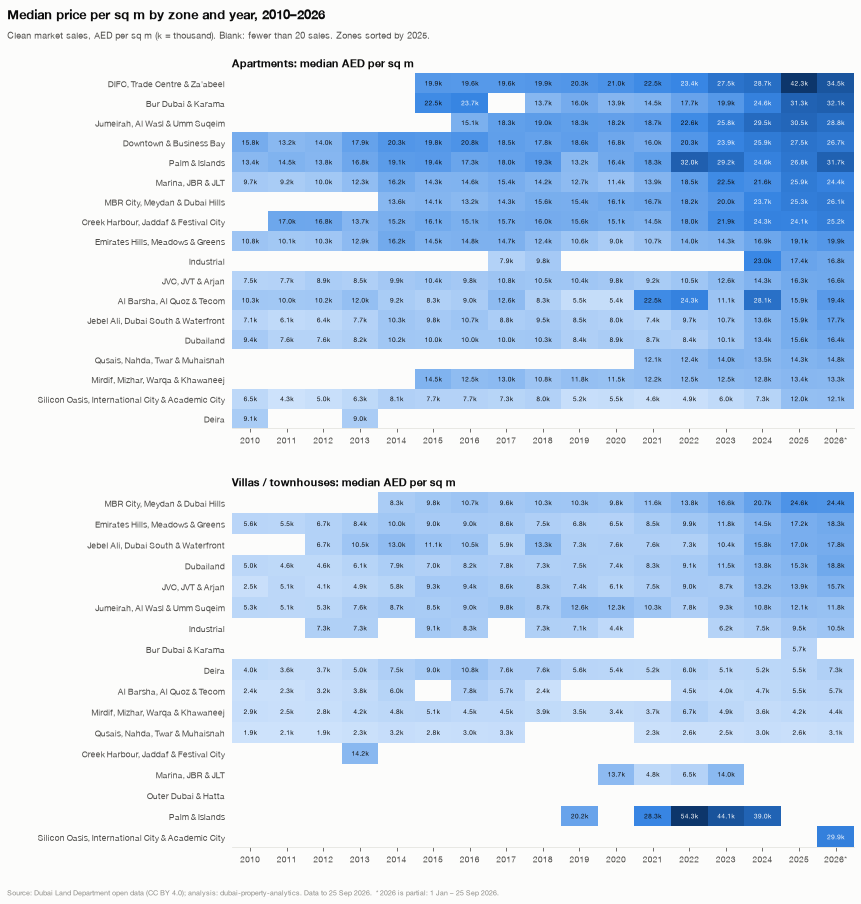

In [4]:
def heatmap(ax, df, value, fmt, title, order=None):
    """Zone × year heatmap on the sequential blue ramp; blank = below min-n."""
    grid = df.pivot(index="zone", columns="year", values=value)
    grid = grid.loc[:, [c for c in grid.columns if c >= 2010]]
    if order is None:
        # Sort by the last complete year (the partial year is thinner and noisier).
        full = [c for c in grid.columns if c < SNAP.year] or list(grid.columns)
        order = grid[full[-1]].sort_values(ascending=False, na_position="last").index
    grid = grid.reindex([z for z in order if z in grid.index])
    ax.imshow(grid.values, aspect="auto", cmap=P.SEQUENTIAL)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_xticklabels([P.year_label(y, SNAP) for y in grid.columns], rotation=0)
    ax.set_yticks(range(grid.shape[0]))
    ax.set_yticklabels(grid.index)
    ax.grid(False)
    vmax = np.nanmax(grid.values)
    for (i, j), v in np.ndenumerate(grid.values):
        if not np.isnan(v):
            ax.text(
                j,
                i,
                fmt(v),
                ha="center",
                va="center",
                fontsize=6.5,
                color="white" if v > 0.55 * vmax else P.TEXT,
            )
    ax.set_title(title)
    return grid


apt_zone = pr.ppsqm_by_zone_year([APT])
villa_zone = pr.ppsqm_by_zone_year([VILLA])
fig, (a1, a2) = P.figure(2, 1, size=(12, 12.5))
fig.subplots_adjust(top=0.92, bottom=0.06, left=0.27, right=0.99, hspace=0.18)
k = lambda v: f"{v / 1000:.1f}k"  # noqa: E731
heatmap(a1, apt_zone, "median_ppsqm_aed", k, "Apartments: median AED per sq m")
heatmap(a2, villa_zone, "median_ppsqm_aed", k, "Villas / townhouses: median AED per sq m")
P.titled(
    fig,
    "Median price per sq m by zone and year, 2010–2026",
    f"Clean market sales, AED per sq m (k = thousand). Blank: fewer than 20 sales. Zones sorted by {SNAP.year - 1}.",
)
P.add_source(fig, SNAP)
P.save(fig, "q3_price_per_sqm_by_zone")
plt.show()

In [5]:
latest, base = SNAP.year - 1, 2019
g = apt_zone.pivot(index="zone", columns="year", values="median_ppsqm_aed")[[base, latest]].dropna()
g["growth"] = g[latest] / g[base] - 1
print(f"Apartments, median AED per sq m, {base} → {latest}:")
display(g.sort_values("growth", ascending=False))

Apartments, median AED per sq m, 2019 → 2025:


year,2019,2025,growth
zone,,,
"Al Barsha, Al Quoz & Tecom","5,499.555","15,918.370",1.894
"Silicon Oasis, International City & Academic City","5,222.220","11,977.625",1.294
"DIFC, Trade Centre & Za'abeel","20,326.255","42,285.100",1.080
"Marina, JBR & JLT","12,687.740","25,929.270",1.044
Palm & Islands,"13,155.610","26,805.430",1.038
Bur Dubai & Karama,"15,966.180","31,317.435",0.961
"Jebel Ali, Dubai South & Waterfront","8,475.690","15,856.430",0.871
Dubailand,"8,351.175","15,558.140",0.863
"Emirates Hills, Meadows & Greens","10,551.490","19,085.340",0.809


## 3. New-contract rent per sq m by zone (residential apartments)

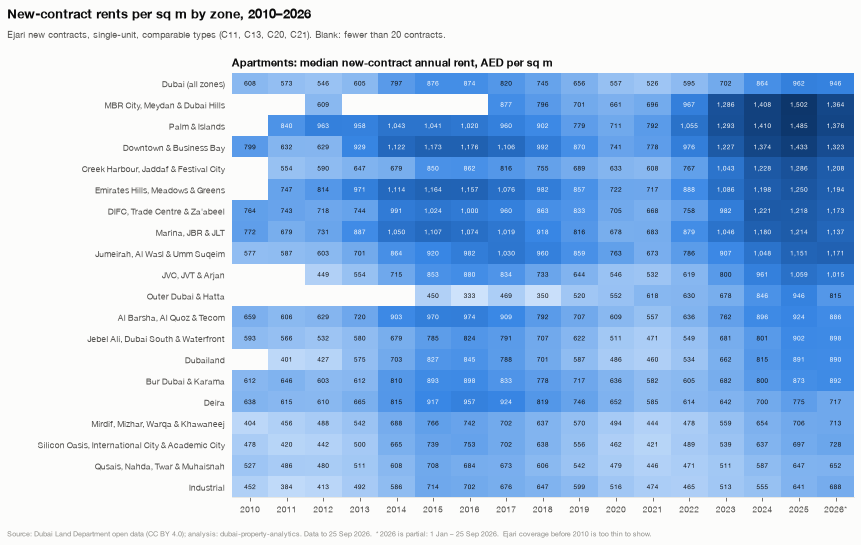

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
zone,,,,,,,,,,,,,,,,,
Dubai (all zones),608.200,572.710,545.570,605.490,796.675,876.400,873.845,820.440,744.670,655.740,557.125,526.500,594.830,702.290,863.640,961.760,946.010


In [6]:
rent_zone = pr.rent_ppsqm_by_zone_year([APT])
fig, ax = P.figure(size=(12, 7.5))
fig.subplots_adjust(top=0.88, bottom=0.08, left=0.27, right=0.99)
order = ["Dubai (all zones)"] + list(
    rent_zone[
        (rent_zone["year"] == SNAP.year - 1) & (rent_zone["zone"] != "Dubai (all zones)")
    ].sort_values("median_rent_ppsqm_aed", ascending=False)["zone"]
)
rent_grid = heatmap(
    ax,
    rent_zone,
    "median_rent_ppsqm_aed",
    lambda v: f"{v:,.0f}",
    "Apartments: median new-contract annual rent, AED per sq m",
    order=order,
)
P.titled(
    fig,
    "New-contract rents per sq m by zone, 2010–2026",
    "Ejari new contracts, single-unit, comparable types (C11, C13, C20, C21). Blank: fewer than 20 contracts.",
)
P.add_source(fig, SNAP, note="Ejari coverage before 2010 is too thin to show.")
P.save(fig, "q3_new_rent_per_sqm_by_zone")
plt.show()
display(rent_grid.loc[["Dubai (all zones)"]])

## 4. Top 10 areas by market-sales value, last 12 months

The 12 calendar months to the snapshot month (Oct 2025 – Sep 2026, the last month partial), the same window as `reports/kpi_reconciliation.md` §3. Growth is against the 12 months before.

,area_name,zone,market_sales,market_value_aed,offplan_share_value,prior_value_aed,share_of_dubai_value,value_growth
0,Business Bay,Downtown & Business Bay,"8,259.000","31,710,553,642.000",0.703,"38,253,343,061.000",0.058,-0.171
1,Madinat Al Mataar,"Jebel Ali, Dubai South & Waterfront","16,177.000","25,234,810,244.000",0.792,"24,987,358,889.000",0.046,0.010
2,Al Yelayiss 1,Dubailand,"4,322.000","23,799,009,900.000",0.493,"25,022,471,093.000",0.043,-0.049
3,Hadaeq Sheikh Mohammed Bin Rashid,"MBR City, Meydan & Dubai Hills","2,990.000","18,745,404,875.000",0.205,"21,986,285,609.000",0.034,-0.147
4,Palm Deira,Palm & Islands,"5,016.000","18,713,409,911.000",0.892,"17,238,582,821.000",0.034,0.086
5,Palm Jumeirah,Palm & Islands,"1,301.000","18,610,902,059.000",0.352,"21,751,522,350.000",0.034,-0.144
6,Al Barsha South Fourth,"JVC, JVT & Arjan","12,376.000","16,542,061,594.000",0.550,"23,235,120,240.000",0.030,-0.288
7,Wadi Al Safa 3,Dubailand,"8,129.000","16,338,662,734.000",0.591,"19,356,487,036.000",0.030,-0.156
8,Marsa Dubai,"Marina, JBR & JLT","3,852.000","15,877,696,132.000",0.396,"32,907,039,994.000",0.029,-0.517
9,Jabal Ali First,"Jebel Ali, Dubai South & Waterfront","8,050.000","15,256,029,648.000",0.625,"16,255,376,390.000",0.028,-0.061


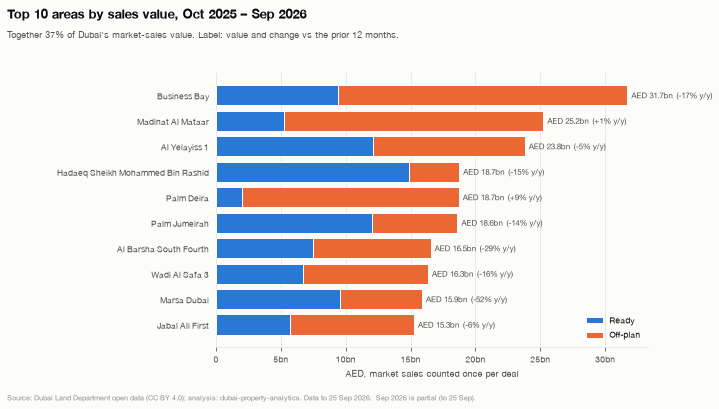

In [7]:
top = pr.top_areas_by_value(SNAP, n=10)
display(top)
fig, ax = P.figure(size=(10, 5.6))
fig.subplots_adjust(left=0.3, top=0.85, right=0.9)
t = top.iloc[::-1]
off = t["market_value_aed"] * t["offplan_share_value"]
ax.barh(
    t["area_name"],
    t["market_value_aed"] - off,
    color=P.SERIES["ready"],
    label="Ready",
    edgecolor=P.SURFACE,
)
ax.barh(
    t["area_name"],
    off,
    left=t["market_value_aed"] - off,
    color=P.SERIES["offplan"],
    label="Off-plan",
    edgecolor=P.SURFACE,
)
for y, (_, r) in enumerate(t.iterrows()):
    ax.text(
        r["market_value_aed"],
        y,
        f"  {P.fmt_aed(r['market_value_aed'])}  ({r['value_growth']:+.0%} y/y)",
        va="center",
        fontsize=8,
        color=P.TEXT_2,
    )
ax.grid(True, axis="x")
ax.grid(False, axis="y")
P.aed_axis(ax, axis="x")
ax.set_xlabel("AED, market sales counted once per deal")
ax.legend(loc="lower right")
P.titled(
    fig,
    "Top 10 areas by sales value, Oct 2025 – Sep 2026",
    f"Together {top['share_of_dubai_value'].sum():.0%} of Dubai's market-sales value. Label: value and change vs the prior 12 months.",
)
P.add_source(fig, SNAP, partial=False, note="Sep 2026 is partial (to 25 Sep).")
P.save(fig, "q3_top10_areas_last12m")
plt.show()

## 5. Mix shift: why the raw median misleads

The raw median AED per sq m of *all* apartment sales changes when **which** apartments sell changes, for example more off-plan units in outer zones. A like-for-like comparison holds the basket fixed. It takes zone × bedroom cells (within apartments) with at least 20 sales in both years, and averages each cell's log change in median AED per sq m, weighted by the earlier year's sales. The gap between the two is the **mix effect**. Function: `prices_rents.like_for_like`.

In [8]:
cells, raw = pr.mix_shift_inputs(APT)
lfl = pr.like_for_like(cells, raw)
display(lfl[lfl["year"] >= 2010].set_index("year"))

,raw_change,lfl_change,mix_effect,cells_used,coverage,median_ppsqm_aed,offplan_share
year,,,,,,,
2010,0.077,0.025,0.052,35,0.990,"9,709.720",0.361
2011,-0.058,-0.142,0.084,33,0.992,"9,144.905",0.110
2012,0.077,0.062,0.015,33,0.984,"9,846.015",0.123
2013,0.130,0.204,-0.074,38,0.989,"11,125.050",0.187
2014,0.162,0.227,-0.065,41,0.969,"12,932.350",0.306
2015,-0.079,-0.036,-0.043,45,0.972,"11,906.950",0.433
2016,-0.009,0.004,-0.012,50,0.955,"11,805.220",0.534
2017,0.056,0.003,0.053,52,0.984,"12,470.980",0.613
2018,0.009,-0.018,0.027,51,0.974,"12,585.070",0.613


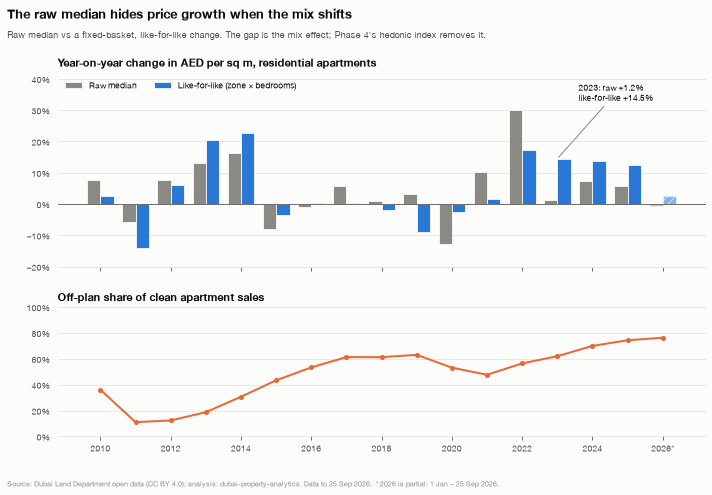

In [9]:
d = lfl[lfl["year"] >= 2010]
ex = d.loc[d["mix_effect"].abs().idxmax()]
fig, (a1, a2) = P.figure(2, 1, size=(10, 6.8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
fig.subplots_adjust(top=0.86, bottom=0.11, hspace=0.25)
w = 0.38
P.year_bars(
    a1, d["year"], d["raw_change"], SNAP, P.SERIES["neutral"], "Raw median", width=w, offset=-w / 2
)
P.year_bars(
    a1,
    d["year"],
    d["lfl_change"],
    SNAP,
    P.SERIES["total"],
    "Like-for-like (zone × bedrooms)",
    width=w,
    offset=w / 2,
)
a1.axhline(0, color=P.TEXT_2, lw=0.8)
P.pct_axis(a1)
a1.set_title("Year-on-year change in AED per sq m, residential apartments")
a1.set_ylim(-0.2, 0.42)
a1.legend(loc="upper left", ncols=2)
a1.annotate(
    f"{int(ex['year'])}: raw {ex['raw_change']:+.1%}\nlike-for-like {ex['lfl_change']:+.1%}",
    (ex["year"], max(ex["raw_change"], ex["lfl_change"])),
    xytext=(ex["year"] + 0.6, 0.33),
    textcoords="data",
    ha="left",
    fontsize=8.5,
    arrowprops={"arrowstyle": "-", "color": P.MUTED},
)
a2.plot(d["year"], d["offplan_share"], color=P.SERIES["offplan"], marker="o", ms=4)
P.pct_axis(a2)
a2.set_ylim(0, 1)
a2.set_title("Off-plan share of clean apartment sales")
P.year_ticks(a2, d["year"], SNAP)
P.titled(
    fig,
    "The raw median hides price growth when the mix shifts",
    "Raw median vs a fixed-basket, like-for-like change. The gap is the mix effect; Phase 4's hedonic index removes it.",
)
P.add_source(fig, SNAP)
P.save(fig, "q3_mix_shift_example")
plt.show()

In [10]:
# The example year in detail: where apartment sales moved (zone share of clean sales).
y1 = int(ex["year"])
mix = cells[cells["year"].isin([y1 - 1, y1])].groupby(["zone", "year"])["n"].sum().unstack()
mix = mix / mix.sum()
med = cells[cells["year"].isin([y1 - 1, y1])].assign(v=lambda x: x["median_ppsqm_aed"] * x["n"])
med = (
    med.groupby(["zone", "year"])["v"].sum() / med.groupby(["zone", "year"])["n"].sum()
).unstack()
detail = mix.join(med, lsuffix="_share", rsuffix="_ppsqm_wtd").sort_values(
    f"{y1}_share", ascending=False
)
print(
    f"Apartment sales mix, {y1 - 1} vs {y1}: share of clean sales by zone, and the zone's sales-weighted cell median"
)
display(detail.head(10))

Apartment sales mix, 2022 vs 2023: share of clean sales by zone, and the zone's sales-weighted cell median


year,2022_share,2023_share,2022_ppsqm_wtd,2023_ppsqm_wtd
zone,,,,
"JVC, JVT & Arjan",0.139,0.214,"10,635.397","12,634.151"
"MBR City, Meydan & Dubai Hills",0.128,0.146,"18,124.297","19,819.798"
"Marina, JBR & JLT",0.135,0.140,"19,216.522","22,510.679"
Downtown & Business Bay,0.204,0.137,"20,589.381","24,019.005"
Dubailand,0.086,0.124,"8,371.705","10,340.079"
"Creek Harbour, Jaddaf & Festival City",0.074,0.060,"18,165.826","21,709.937"
"Jebel Ali, Dubai South & Waterfront",0.044,0.039,"9,808.680","10,341.313"
"Silicon Oasis, International City & Academic City",0.034,0.032,"4,904.825","6,137.137"
"Jumeirah, Al Wasl & Umm Suqeim",0.063,0.027,"22,903.919","26,298.550"


## 6. Gross yield by zone: **preview, proper yields in Phase 4**

Median annual rent (new market rents) ÷ median price (**ready** clean sales, because an off-plan unit earns no rent yet), over the last 12 months to the snapshot, per zone × class × bedrooms, with at least 20 observations on each side. A zone's figure is the sales-weighted mean of its bedroom cells, and it rolls up to zone × class medians where no bedroom cell passes. Cells outside the docs/04 sanity band (2–15%) are flagged and left out.

Phase 4 computes yields properly (area × sub-type × bedrooms × quarter, with the min-n roll-up) in `agg_yield_quarter`.

In [11]:
yc = pr.yield_preview_cells(SNAP)
yz = pr.yield_by_zone(yc)
print("Cells outside the 2–15% sanity band:")
display(yc[yc["is_outside_sanity"]])
display(yz.sort_values(["property_type_label", "gross_yield"], ascending=[True, False]))

Cells outside the 2–15% sanity band:


,zone,property_type_key,property_type_label,bedrooms,is_rollup,sales_n,median_price_aed,rent_n,median_annual_rent_aed,gross_yield,is_outside_sanity
3,"Al Barsha, Al Quoz & Tecom",101,Residential · Apartment,3.000,False,97,"662,500.000",321,"134,000.000",0.202,True


,zone,property_type_label,gross_yield,method,sales_n,rent_n,cells_flagged
32,"Silicon Oasis, International City & Academic City",Residential · Apartment,0.098,bedroom cells,1936,18594,0
13,Industrial,Residential · Apartment,0.088,bedroom cells,173,4577,0
17,"Jebel Ali, Dubai South & Waterfront",Residential · Apartment,0.079,bedroom cells,2742,14157,0
0,"Al Barsha, Al Quoz & Tecom",Residential · Apartment,0.075,bedroom cells,454,7036,1
9,Dubailand,Residential · Apartment,0.075,bedroom cells,7156,22037,0
15,"JVC, JVT & Arjan",Residential · Apartment,0.073,bedroom cells,6092,27644,0
11,"Emirates Hills, Meadows & Greens",Residential · Apartment,0.062,bedroom cells,457,1758,0
21,"MBR City, Meydan & Dubai Hills",Residential · Apartment,0.062,bedroom cells,3053,13275,0
8,Downtown & Business Bay,Residential · Apartment,0.058,bedroom cells,3810,16189,0
23,"Marina, JBR & JLT",Residential · Apartment,0.058,bedroom cells,3497,15129,0


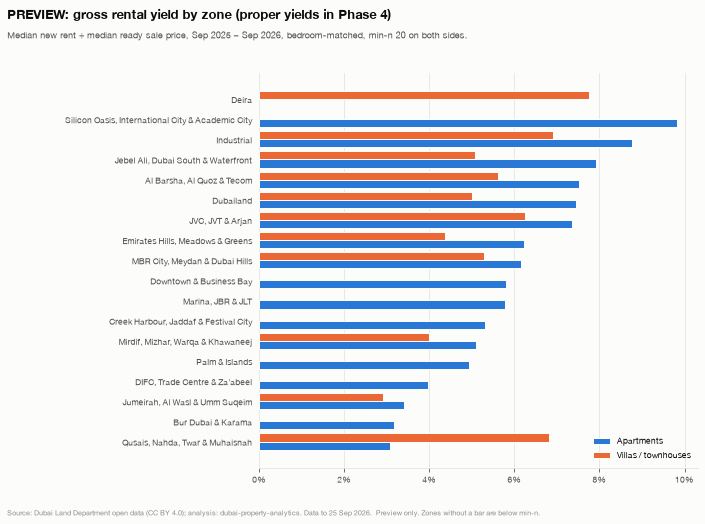

In [12]:
yz_ = yz.dropna(subset=["gross_yield"])
order = (
    yz_[yz_["property_type_label"].str.contains("Apartment")]
    .sort_values("gross_yield")["zone"]
    .tolist()
)
order += [z for z in yz_["zone"].unique() if z not in order]
fig, ax = P.figure(size=(10, 7.2))
fig.subplots_adjust(left=0.36, top=0.87, bottom=0.1, right=0.97)
h = 0.4
for i, (label, series, off) in enumerate(
    [("Apartment", "apartment", -h / 2), ("Villa", "villa", h / 2)]
):
    s = yz_[yz_["property_type_label"].str.contains(label)].set_index("zone").reindex(order)
    ypos = np.arange(len(order)) + off
    ax.barh(
        ypos,
        s["gross_yield"],
        height=h,
        color=P.SERIES[series],
        label="Apartments" if i == 0 else "Villas / townhouses",
        edgecolor=P.SURFACE,
    )
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.grid(True, axis="x")
ax.grid(False, axis="y")
P.pct_axis(ax, axis="x")
ax.legend(loc="lower right")
P.titled(
    fig,
    "PREVIEW: gross rental yield by zone (proper yields in Phase 4)",
    "Median new rent ÷ median ready sale price, Sep 2025 – Sep 2026, bedroom-matched, min-n 20 on both sides.",
)
P.add_source(fig, SNAP, partial=False, note="Preview only. Zones without a bar are below min-n.")
P.save(fig, "q4_gross_yield_preview_by_zone")
plt.show()

## Findings

1. **Villas have caught up with apartments per sq m.** The median apartment price rose from AED 11,314 per sq m (2020) to 18,657 (2025), +65%. Villas / townhouses rose from 7,528 to 15,700, +109%. In 2026 to date, the villa median (18,672) is above the apartment median (18,568) for the first time in the series.
2. **Zone growth ranges from +13% to +108%.** The median apartment price per sq m from 2019 to 2025 rose +108% in DIFC, Trade Centre & Za'abeel (to AED 42,285), +104% in Marina, JBR & JLT and +104% in Palm & Islands, but only +13% in Mirdif, Mizhar, Warqa & Khawaneej. The +189% in Al Barsha, Al Quoz & Tecom is mostly mix: that zone blends Tecom towers with Al Quoz.
3. **New rents rose faster than prices from the 2021 low.** The Dubai-wide median new apartment rent went from AED 526 per sq m a year (2021) to 962 (2025), +83%. The highest in 2025 were MBR City, Meydan & Dubai Hills (1,502), Palm & Islands (1,485) and Downtown & Business Bay (1,433).
4. **Sales value is concentrated and mostly off-plan.** Over Oct 2025 – Sep 2026 the top 10 areas took 37% of market-sales value. Business Bay leads with AED 31.7bn (70% off-plan), followed by Madinat Al Mataar with AED 25.2bn (79% off-plan).
5. **The raw median understated 2023–25 growth.** In 2023 the raw apartment median rose 1.2%, but like-for-like (zone × bedrooms) it rose 14.5%. Sales shifted to cheaper zones: JVC, JVT & Arjan went from 13.9% to 21.4% of apartment sales, and Downtown & Business Bay fell from 20.4% to 13.7%. 2024 (+7.3% raw vs +13.6%) and 2025 (+5.8% vs +12.4%) point the same way; 2022 ran the other way (+30.2% vs +17.4%). **Phase 4 implication:** a raw median confounds composition with price, so the price index must be hedonic (time dummies with location and unit controls), not a median.
6. **Gross yield preview (proper yields in Phase 4).** Apartment gross yields range from 3.1–3.4% in the older and prime zones (Qusais roll-up, Bur Dubai & Karama, Jumeirah) to 7.3–9.8% in outer and value zones (JVC, Dubailand, Jebel Ali / Dubai South, Silicon Oasis). Villa yields run from 2.9% (Jumeirah) to 7.8% (Deira, roll-up). 5 zone × class segments are below min-n, and 1 bedroom cell (Al Barsha 3-bed, 20%) is outside the 2–15% sanity band and left out.